# Session 1 - Build NN with Tensor , compile, train , evaluate (tensorboard) - Architecture

## Install required tools - Check

In [1]:
from gc import callbacks

import tensorflow
import torch
import torchvision
from keras.src.layers import Lambda

In [2]:
print(tensorflow.__version__)
print(torch.__version__)
print(torchvision.__version__)


2.21.0
2.11.0+cu128
0.26.0+cu128


## Tensor params for building an NN

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,InputLayer,Conv2D,MaxPooling2D,Dropout, Flatten
from tensorflow.keras.metrics import MSE
from tensorflow.keras.losses import MeanSquaredError,categorical_crossentropy,binary_crossentropy
from tensorflow.keras.utils import plot_model,to_categorical,image_dataset_from_directory
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,EarlyStopping

from tensorflow.keras.backend import backend


### 1. Model building

| Import       | What it is                              | Typical use                      | Importance |
| ------------ | --------------------------------------- | -------------------------------- | ---------- |
| `Sequential` | Model where layers are stacked in order | Simple feed-forward/CNN models   | ⭐⭐⭐⭐⭐      |
| `InputLayer` | Defines the shape of model input        | Explicitly specify input shape   | ⭐⭐⭐        |
| `Dense`      | Fully connected neural-network layer    | Classification, regression, MLPs | ⭐⭐⭐⭐⭐      |

Example:

```python
model = Sequential([
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1)
])
```

---

### 2. CNN layers

| Import         | What it is                               | Typical use               | Importance |
| -------------- | ---------------------------------------- | ------------------------- | ---------- |
| `Conv2D`       | 2D convolution layer                     | Images / computer vision  | ⭐⭐⭐⭐⭐      |
| `MaxPooling2D` | Downsamples feature maps                 | Reduce spatial dimensions | ⭐⭐⭐⭐       |
| `Flatten`      | Converts 2D/3D feature maps → 1D vector  | CNN → Dense layers        | ⭐⭐⭐⭐       |
| `Dropout`      | Randomly removes neurons during training | Reduce overfitting        | ⭐⭐⭐⭐⭐      |

Typical CNN:

```text
Image
  ↓
Conv2D
  ↓
ReLU
  ↓
MaxPooling
  ↓
Conv2D
  ↓
Flatten
  ↓
Dense
  ↓
Output
```

---

### 3. Metrics

```python
from tensorflow.keras.metrics import MSE
```

**MSE = Mean Squared Error**

Measures how far predictions are from the true values.

$$
MSE = \frac{1}{n}\sum (y-\hat y)^2
$$

Usually used for **regression**.

```python
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)
```

Important distinction:

**Loss** → what the model optimizes.

**Metric** → what you use to evaluate/monitor performance.

They can be the same, but don't have to be.

---

### 4. Loss functions

```python
MeanSquaredError
categorical_crossentropy
binary_crossentropy
```

These are **very important**.

| Loss                       | Problem                                        |
| -------------------------- | ---------------------------------------------- |
| `MeanSquaredError`         | Regression                                     |
| `binary_crossentropy`      | Binary classification                          |
| `categorical_crossentropy` | Multi-class classification with one-hot labels |

For example:

**Binary classification**

```text
Cancer / No Cancer
0 / 1
```

→ `binary_crossentropy`

**3-class classification**

```text
Healthy
Disease A
Disease B
```

with one-hot labels:

```text
[1,0,0]
[0,1,0]
[0,0,1]
```

→ `categorical_crossentropy`

---

### 5. Dataset / preprocessing utilities

```python
to_categorical
image_dataset_from_directory
```

#### `to_categorical`

Converts class numbers into one-hot vectors.

```python
[0, 2, 1]
```

becomes approximately:

```text
[1,0,0]
[0,0,1]
[0,1,0]
```

Very useful for **multi-class classification**.

#### `image_dataset_from_directory`

Loads images organized in folders.

```text
dataset/
    cats/
    dogs/
```

Keras can automatically infer the labels.

Very useful for **CNN/image classification**.

---

### 6. Visualization

```python
plot_model
```

Creates a diagram of your neural network.

For example:

```text
Input
  ↓
Dense(128)
  ↓
Dense(64)
  ↓
Dense(10)
```

Useful for understanding the **architecture/computational flow**.

---

### 7. Optimizers

```python
Adam
SGD
```

These are **extremely important**.

The optimizer determines **how model parameters are updated using gradients**.

Very simplified:

$$
\theta_{new} = \theta_{old} - \eta\nabla_\theta L
$$

#### SGD

**Stochastic Gradient Descent**

Basic gradient-based optimization.

```python
SGD(learning_rate=0.01)
```

#### Adam

Adaptive optimization algorithm combining ideas from momentum and adaptive learning rates.

```python
Adam(learning_rate=0.001)
```

In practice, **Adam is one of the first optimizers you'll commonly encounter**.

---

### 8. Text preprocessing

```python
Tokenizer
```

Converts text into numerical representations that a neural network can process.

For example:

```text
"I love biology"
```

might become:

```text
[4, 7, 12]
```

Historically very common in Keras NLP pipelines.

However, for modern NLP/LLMs you'll also encounter **subword tokenizers**, such as BPE/WordPiece/SentencePiece-style tokenization.

---

### 9. Regularization

```python
l1_l2
```

Adds penalties to model weights to help control overfitting.

Conceptually:

$$
Loss_{total}=Loss_{data}+\lambda_1\sum |w|
+\lambda_2\sum w^2
$$

**L1** → encourages some weights toward zero.

**L2** → discourages excessively large weights.

Very useful conceptually because regularization is one of the fundamental ways we control **generalization vs. overfitting**.

---

### 10. Callbacks

These are tools that automatically react during training.

```python
ModelCheckpoint
ReduceLROnPlateau
EarlyStopping
```

#### `ModelCheckpoint`

Saves model weights/model when a condition is met.

Example:

```text
Epoch 1 → val_loss = 0.50
Epoch 2 → val_loss = 0.40 ← save
Epoch 3 → val_loss = 0.45
```

You can preserve the best model.

#### `EarlyStopping`

Stops training when performance stops improving.

```text
Epoch 10 → improving
Epoch 11 → improving
Epoch 12 → no improvement
Epoch 13 → no improvement
Epoch 14 → no improvement
STOP
```

Helps prevent unnecessary training and potentially overfitting.

#### `ReduceLROnPlateau`

If validation performance stops improving, reduce the learning rate.

```text
learning rate:
0.001
   ↓
0.0001
   ↓
0.00001
```

Very useful when training gets stuck around a plateau.

---

## One thing in your import is incomplete

You wrote:

```python
from tensorflow.keras.backend import backend
```

If the purpose was to access Keras backend functionality, this isn't something I'd prioritize at this stage. **Backend APIs are much less important for you right now** than understanding layers, losses, optimizers, gradients, and training.

---

# What I would prioritize for your Deep Learning course


## And there are some important things missing

From this first-session list, I'd also expect you to encounter:

```python
Activation
BatchNormalization
GlobalAveragePooling2D
Embedding
LSTM
GRU
MultiHeadAttention
```

and, depending on how modern your course is:

```text
Tensor
GradientTape
tf.data
Data augmentation
Transfer learning
Learning-rate scheduling
```

Later, for your **LLM/Transformer + computational biology goals**, these become especially important:

```text
Embedding
Attention
Multi-Head Attention
Positional Encoding
Transformer
Transfer Learning
Fine-tuning
```

### The big picture

You can organize almost everything you've seen so far into this mental map:

```text
                 DEEP LEARNING
                      │
       ┌──────────────┼──────────────┐
       ↓              ↓              ↓
    MODEL           TRAINING       DATA
       │              │              │
    Dense          Loss           Dataset
    Conv2D         Optimizer      Tokenizer
    Dropout        Gradient       Images
    Flatten        Backprop
       │              │
       └──────┬───────┘
              ↓
          EVALUATION
              │
       Metrics / Validation
              │
              ↓
        GENERALIZATION
              │
       Dropout / L1 / L2
       EarlyStopping
```

**Most important next step:** don't just memorize these APIs. We should now connect them to **what actually happens mathematically during `model.fit()`**—forward pass → loss → computational graph → backpropagation → gradients → optimizer → weight update. That's where the real Deep Learning understanding starts.

`utils` is short for **utilities**.

In programming libraries, a `utils` module usually contains **helper functions/tools** that make common tasks easier, but aren't themselves the main model or algorithm.

In your code:

```python
from tensorflow.keras.utils import plot_model, to_categorical, image_dataset_from_directory
```

These are helper tools:

* `plot_model()` → visualize your neural network architecture.
* `to_categorical()` → convert class labels into one-hot encoded vectors.
* `image_dataset_from_directory()` → load images from folders into a TensorFlow dataset.

So think:

```text
tensorflow.keras
│
├── models      → build models
├── layers      → neural-network layers
├── losses      → loss functions
├── optimizers  → update weights
├── metrics     → evaluate models
├── callbacks   → actions during training
└── utils       → useful helper tools
```

**Key idea:** `utils` isn't a special Deep Learning concept. It's mainly an organizational name meaning **"miscellaneous useful utilities/helpers."**


In [4]:
from tensorflow.keras import models
type1 = models.Sequential()
type2 = Sequential()

In [5]:
model = Sequential([
    InputLayer(input_shape=(5,)),
    Flatten(name='flatten'),
    Dense(100, activation='relu',name='dense1' ),
    Dense(50, activation='relu',name='dense2' ),
],name="My Model")
model.summary()

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "My Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 100)            │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 50)             │         5,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,650 (22.07 KB)

 Trainable params: 5,650 (22.07 KB)

 Non-trainable params: 0 (0.00 B)

### Mnist with Tensor

In [6]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape,X_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [7]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)
print(X_train.shape,X_test.shape)


(60000, 784) (10000, 784)


In [8]:
## With MLP
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(
    hidden_layer_sizes=(32,32),
    activation="relu",
    solver="adam",
    max_iter=500,
    learning_rate_init=0.01,
    verbose=0,
    tol=1e-4,
    early_stopping=True,

)

model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32, ...)"
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in eac

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       980
           1       0.94      0.95      0.95      1135
           2       0.91      0.89      0.90      1032
           3       0.90      0.82      0.86      1010
           4       0.85      0.89      0.87       982
           5       0.76      0.79      0.78       892
           6       0.91      0.91      0.91       958
           7       0.88      0.92      0.90      1028
           8       0.88      0.75      0.81       974
           9       0.81      0.84      0.83      1009

    accuracy                           0.88     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.88      0.88      0.88     10000



<Axes: >

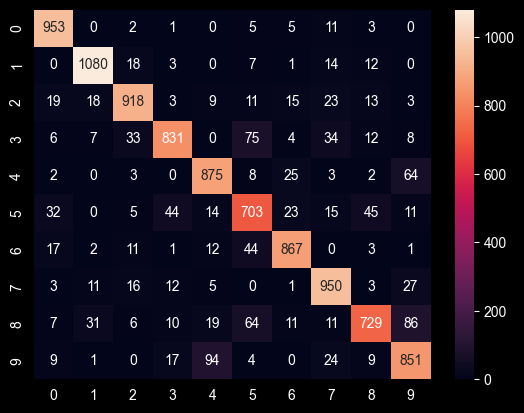

In [9]:
import  seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,model.predict(X_test)))
sns.heatmap(confusion_matrix(y_test,model.predict(X_test)),annot=True,fmt='g')

In [10]:
## with tensor
nn = Sequential([
    InputLayer(shape=(784,)),
    Flatten(),
    Dense(32, activation='relu',name='dense1' ),
    Dense(32, activation='relu',name='dense2' ),
    Dense(32, activation='relu',name='dense3' ),
    Dense(10, activation='softmax',name='softmax' ),
])
nn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,562 (107.66 KB)

 Trainable params: 27,562 (107.66 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
## compile model
adam = Adam(learning_rate=0.001)
nn.compile(optimizer=adam,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [12]:
history = nn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7413 - loss: 1.2463
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8914 - loss: 0.4169
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9091 - loss: 0.3318
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9193 - loss: 0.2892
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9247 - loss: 0.2655
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9294 - loss: 0.2436
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9348 - loss: 0.2269
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9403 - loss: 0.2091
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9426 - loss: 0.1992
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9448 - loss: 0.1904


In [13]:
history.history

{'accuracy': [0.741266667842865,
  0.8914499878883362,
  0.9091166853904724,
  0.9192833304405212,
  0.9247333407402039,
  0.9294166564941406,
  0.9347500205039978,
  0.9402999877929688,
  0.9425833225250244,
  0.9447500109672546],
 'loss': [1.2462953329086304,
  0.41691309213638306,
  0.33183977007865906,
  0.28921154141426086,
  0.265468955039978,
  0.24355420470237732,
  0.22687089443206787,
  0.20906776189804077,
  0.19917501509189606,
  0.19037215411663055]}

(0.0, 1.0)

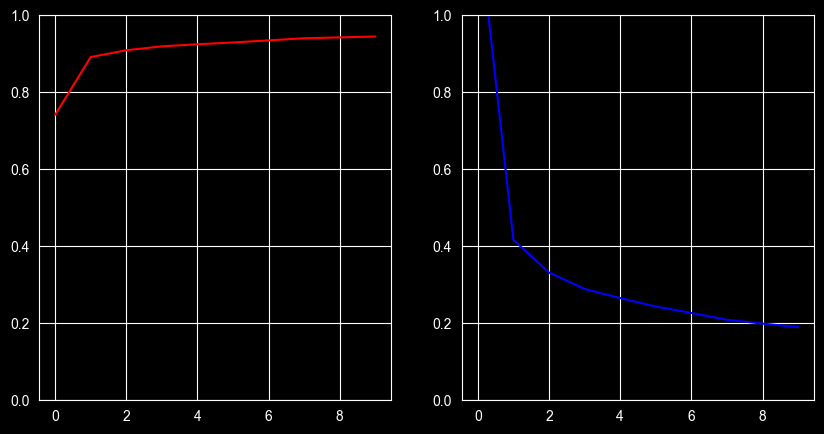

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],'r',label='train_accuracy')
plt.ylim(0,1)

plt.subplot(1,2,2)
plt.plot(history.history['loss'],'b',label='train_loss')
plt.ylim(0,1)

In [15]:
import numpy as np
y_pred = nn.predict(X_test)
y_pred = np.argmax(y_pred,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step


In [16]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.94      0.99      0.96       980
           1       0.98      0.99      0.98      1135
           2       0.96      0.91      0.94      1032
           3       0.90      0.94      0.92      1010
           4       0.87      0.97      0.92       982
           5       0.98      0.88      0.92       892
           6       0.96      0.97      0.97       958
           7       0.95      0.92      0.93      1028
           8       0.90      0.95      0.92       974
           9       0.94      0.84      0.89      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



<Axes: >

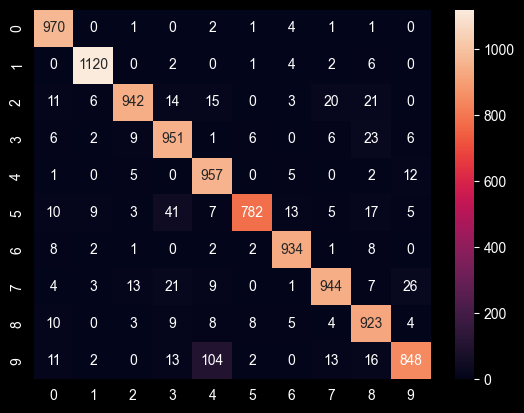

In [17]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='g')

#### Extra points


Yes. This example is introducing **three ways to add your own behavior to a Keras model**:

1. a **custom layer**
2. a **custom function**
3. `Lambda` to put a function inside the model

The key difference is **how much control you need**.

---

## 1. `my_function(X)` — just a custom operation

```python
def my_function(X):
    return X * 2
```

This is simply a normal Python function.

For example:

```python
x = 5
my_function(x)
```

→ `10`

In a neural network, you might want to perform some operation that Keras doesn't provide as a built-in layer.

For example:

```python
def my_function(X):
    return X * 2
```

Then:

```python
layers.Lambda(my_function)
```

means:

> "Take the output coming into this point and apply `my_function` to it."

So:

```text
Dense(32)
    ↓
X
    ↓
my_function(X) = X × 2
    ↓
Dense(32)
```

---

# 2. `Lambda` — put a small function inside the model

This:

```python
layers.Lambda(my_function)
```

takes a Python function and turns it into a **Keras layer**.

Example:

```python
def my_function(X):
    return X * 2

model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Lambda(my_function),
    layers.Dense(10, activation="softmax")
])
```

Now the Lambda layer performs:

$$
X \rightarrow 2X
$$

### Real-world use

Suppose you need a simple transformation:

```python
def normalize(X):
    return X / 255.0
```

You could put it into the model:

```python
layers.Lambda(normalize)
```

So:

```text
raw image
   ↓
Flatten
   ↓
Dense
   ↓
divide by 255
   ↓
Dense
```

### When should you use Lambda?

Use it for **small, simple operations**.

Examples:

```python
Lambda(lambda x: x * 2)
Lambda(lambda x: x / 255.0)
Lambda(lambda x: x + 1)
```

But you generally **shouldn't use Lambda for complicated learnable behavior**.

---

# 3. `MyCustomLayer` — create your own actual neural-network layer

This is more powerful.

You have:

```python
class MyCustomLayer(layers.Layer):
    def build(self, input_shape):
        pass
```

You're saying:

> "I want to create a new type of Keras layer myself."

For example, imagine you want a layer that does:

$$
y = xw + b
$$

with **weights that the network learns**.

You could create:

```python
class MyCustomLayer(layers.Layer):

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(1,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):
        return inputs @ self.w + self.b
```

Then:

```python
model = models.Sequential([
    layers.Input(shape=(784,)),
    MyCustomLayer(),
    layers.Dense(10, activation="softmax")
])
```

Now your custom layer has **trainable parameters**.

During training:

```text
input
  ↓
MyCustomLayer
  ↓
y = XW + b
  ↓
loss
  ↓
backpropagation
  ↓
update W and b
```

That's a real neural-network layer.

---

# Why do we need `build()`?

This part is important.

```python
def build(self, input_shape):
```

`build()` is where you create weights whose size depends on the input.

For example, if:

```text
input shape = (None, 784)
```

then you know the number of input features is:

```text
784
```

So you can create:

```python
self.w = self.add_weight(
    shape=(784, 32)
)
```

But you may not know `784` beforehand.

That's why Keras gives you:

```python
input_shape
```

and you can do:

```python
input_shape[-1]
```

---

# And `call()`?

Your example only has:

```python
def build(self, input_shape):
    pass
```

but a custom layer normally also needs:

```python
def call(self, inputs):
    ...
```

Think:

```text
build()
   ↓
Create the parameters/weights

call()
   ↓
Define what the layer DOES with the input
```

For example:

```python
class MyCustomLayer(layers.Layer):

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], 32),
            trainable=True
        )

    def call(self, inputs):
        return inputs @ self.w
```

---

# The three concepts together

Think about them this way:

|                    | Function        | Lambda                           | Custom Layer         |
| ------------------ | --------------- | -------------------------------- | -------------------- |
| What?              | Python function | Function packaged as Keras layer | Your own Keras layer |
| Trainable weights? | ❌               | Usually ❌                        | ✅                    |
| Simple operation?  | ✅               | ✅                                | ✅                    |
| Complex behavior?  | Limited         | Not ideal                        | ✅                    |
| Custom parameters? | ❌               | Not normally                     | ✅                    |
| Used in `model`?   | Not directly    | ✅                                | ✅                    |

### Mental model

```text
Normal Python operation
        │
        ↓
   my_function()
        │
        │ Lambda wraps it
        ↓
   Lambda layer
        │
        │
        │ Need trainable weights/
        │ complex behavior?
        ↓
   Custom Layer
```

---

## Real-world analogy

Imagine you're building a factory.

**Function:**

> "Take this product and double its size."

Just an operation.

**Lambda:**

> "Put that small operation into my factory pipeline."

**Custom Layer:**

> "I'm designing an entirely new machine for the factory, with adjustable parameters that the machine can learn."

---

### For your current Deep Learning level

You **do not need to start writing custom layers yet**.

For now, remember:

```text
Dense / Conv2D / Dropout
        ↓
built-in Keras layers

Lambda
        ↓
small custom mathematical operation

Custom Layer
        ↓
build your own learnable layer/architecture
```

The **custom layer concept becomes much more important later** when you study things like **attention, Transformer components, specialized biological models, and research implementations**.


In [19]:
# Customize your layer when is simple with lambda
from tensorflow.keras import layers
def normalize(X):
    return X / 255.0
model_new = Sequential([
    InputLayer(shape=(784,)),
    Flatten(),
    Dense(32, activation='relu',name='dense1' ),
    layers.Lambda(normalize),
    layers.Dense(32, activation='relu',name='dense2' ),
])

model_new.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32)             │         1,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,176 (102.25 KB)

 Trainable params: 26,176 (102.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
## when layer is more complex such as has trainable params
class MyCustomLayer(layers.Layer):
    def build(self, input_shape):
        self.W = self.add_weight(name='weight',shape=(input_shape[-1],1),
        initializer='random_normal',
        trainable=True)

        self.bias = self.add_weight(name='bias',
        initializer='random_normal',shape =(1,),
                                    trainable=True


        )

    def call(self,inputs):
            return  inputs @ self.W +self.bias



In [21]:
model = Sequential([
    layers.Input(shape=(784,)),
    Flatten(),
    Dense(32, activation='relu', name='dense1'),
    MyCustomLayer(),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_custom_layer (MyCustomLayer) │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,173 (98.33 KB)

 Trainable params: 25,173 (98.33 KB)

 Non-trainable params: 0 (0.00 B)



# Now the important part: what is `inputs`?

This is probably the most important thing to understand.

When you write:

```python
def call(self, inputs):
```

`inputs` means:

> **the tensor containing the data coming into this layer.**

It is NOT a special keyword.

You could technically write:

```python
def call(self, x):
```

and then:

```python
return x @ self.W + self.bias
```

That's exactly the same idea.

---

## Follow the data through your model

You have:

```python
Input(shape=(784,))
```

Suppose your batch size is 32.

The data starts as:

```text
X
shape = (32, 784)
```

Then:

```python
Dense(32)
```

produces:

```text
shape = (32, 32)
```

Then your custom layer receives that output.

Therefore, inside:

```python
def call(self, inputs):
```

`inputs` is:

```text
shape = (32, 32)
```

Conceptually:

```text
X
│
│ (32, 784)
↓
Dense(32)
│
│ (32, 32)
↓
MyCustomLayer
│
│ inputs = (32, 32)
↓
inputs @ W + bias
```

---

# What is `self.W`?

This is a **trainable parameter of your layer**.

You created:

```python
self.W = self.add_weight(
    shape=(input_shape[-1], 1),
    initializer='random_normal',
    trainable=True
)
```

Because the previous layer has 32 outputs:

```text
input_shape[-1] = 32
```

so:

```text
W shape = (32, 1)
```

Then:

$$
(32,32) @ (32,1) = (32,1)
$$

That's ordinary matrix multiplication.

---

# What does `initializer` mean?

This:

```python
initializer='random_normal'
```

means:

> **How should the weights be initialized before training starts?**

The model needs initial values for `W`.

For example, it might start with something conceptually like:

```text
W =
[ 0.02
 -0.01
  0.03
  ...
]
```

These are random values sampled from a normal distribution.

Then training changes them.

There are many initializers, such as:

```python
initializer="zeros"
initializer="ones"
initializer="random_normal"
initializer="glorot_uniform"
initializer="he_normal"
```

For neural networks, the choice of initialization can affect training.

For example, **He initialization** is commonly associated with ReLU networks.

---

# What does `trainable=True` mean?

This is extremely important.

```python
trainable=True
```

means:

> **The optimizer is allowed to change this parameter during training.**

Suppose initially:

```text
W = 0.02
```

During training:

```text
forward pass
     ↓
calculate loss
     ↓
backpropagation
     ↓
calculate ∂Loss/∂W
     ↓
Adam
     ↓
change W
```

For example, conceptually:

```text
W = 0.02
 ↓
W = 0.018
 ↓
W = 0.015
 ↓
W = 0.021
 ...
```

The exact values depend on the data and gradients.

---

# Why is `trainable=True` important?

Compare:

```python
self.W = self.add_weight(
    shape=(32, 1),
    trainable=True
)
```

with:

```python
self.W = self.add_weight(
    shape=(32, 1),
    trainable=False
)
```

### `True`

```text
W
↓
gradient calculated
↓
optimizer updates W
```

### `False`

```text
W
↓
used in calculation
↓
NOT updated by optimizer
```

So:

**trainable parameter = something the neural network learns.**

---

# Your custom layer is basically creating this

Your layer:

```python
return inputs @ self.W + self.bias
```

is essentially implementing a simplified **Dense layer**.

Mathematically:

$$
Y = XW+b
$$

That's exactly the fundamental operation inside a fully connected layer.

So your custom layer is basically saying:

> "Instead of using Keras's `Dense`, I want to manually create my own layer that performs \(XW+b\)."

That's why custom layers are useful: you can implement **your own mathematical operation**, including learnable parameters.

---

## One more correction: your bias shape

You currently have:

```python
shape=(input_shape[-1],)
```

which gives:

```text
bias shape = (32,)
```

But your output is:

```text
(batch, 1)
```

So a more natural bias is:

```python
shape=(1,)
```

giving:

```text
X @ W       + bias
(32,1)        (1,)
```

and broadcasting handles the batch dimension.

---

### The whole concept in one picture

```text
             TRAINABLE PARAMETERS
                  W and bias
                     ↑
                     │
Input ───────→ call(inputs) ───────→ Output
                     │
                     │
              inputs @ W + bias
                     │
                     ↓
                  result

initializer
    ↓
initial values of W/bias

trainable=True
    ↓
optimizer can change W/bias

call(inputs)
    ↓
defines what your layer actually does
```

**The key distinction to remember:**

> `inputs` = data coming **into** your layer.

> `W` and `bias` = parameters **belonging to** your layer.

> `initializer` = how those parameters get their **initial values**.

> `trainable=True` = those parameters can be **learned/updated during training**.


In [22]:
### Callback Custome
from tensorflow.keras import callbacks
class MyCallBack(callbacks.Callback):
    def on_train_begin(self, logs={}):
        print('train_begin')
    def on_train_end(self, logs=None):
        print("Train end")

    def on_epoch_begin(self, epoch, logs=None):
        print("\tEpoch begin")

    def on_epoch_end(self, epoch, logs=None):
        print("\tEpoch end")


In [23]:
callback = MyCallBack()
his = nn.fit(
    X_train,
    y_train,
    epochs=5,
    callbacks=[callback],
)

train_begin
	Epoch begin
Epoch 1/5
1859/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9467 - loss: 0.1819	Epoch end
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9468 - loss: 0.1817
	Epoch begin
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9489 - loss: 0.1761	Epoch end
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9489 - loss: 0.1761
	Epoch begin
Epoch 3/5
1835/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9509 - loss: 0.1684	Epoch end
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9510 - loss: 0.1685
	Epoch begin
Epoch 4/5
1862/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9531 - loss: 0.1624	Epoch end
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9530 - loss: 0.1627
	Epoch begin
Epoch 5/5
1859/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9538 - loss: 0.1605	Epoch end
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9540 - loss: 0.1598
Train end


This is a **custom Keras callback**. A callback is basically a way to tell Keras:

> “When a particular training event happens, run my code.”

Your code is creating hooks into different stages of `model.fit()`.

### Your callback

```python
from tensorflow.keras.callbacks import Callback

class MyCallBack(Callback):

    def on_train_begin(self, logs={}):
        print("Train begin")

    def on_train_end(self, logs=None):
        print("Train end")

    def on_epoch_begin(self, epoch, logs=None):
        print("\tEpoch begin")

    def on_epoch_end(self, epoch, logs=None):
        print("\tEpoch end")
```

Then you would use it:

```python
callback = MyCallBack()

history = model.fit(
    X_train,
    y_train,
    epochs=3,
    callbacks=[callback]
)
```

The output will be roughly:

```text
Train begin

    Epoch begin
    Epoch end

    Epoch begin
    Epoch end

    Epoch begin
    Epoch end

Train end
```

## What each method means

Think about `fit()` as a hierarchy:

```text
TRAINING
│
├── on_train_begin()
│
├── Epoch 1
│   ├── batches...
│   └── on_epoch_end()
│
├── Epoch 2
│   ├── batches...
│   └── on_epoch_end()
│
├── Epoch 3
│   ├── batches...
│   └── on_epoch_end()
│
└── on_train_end()
```

### `on_train_begin()`

Runs **once before all epochs start**.

```python
def on_train_begin(self, logs=None):
    print("Train begin")
```

Useful for initializing something.

---

### `on_epoch_begin()`

Runs at the **beginning of every epoch**.

```python
def on_epoch_begin(self, epoch, logs=None):
    print("Epoch begin")
```

`epoch` tells you which epoch you're currently in.

For example:

```text
epoch = 0  → first epoch
epoch = 1  → second epoch
epoch = 2  → third epoch
```

---

### `on_epoch_end()`

Runs at the **end of every epoch**.

This one is particularly useful because `logs` contains information about that epoch.

For example:

```python
def on_epoch_end(self, epoch, logs=None):
    print(logs)
```

You might see something like:

```python
{
    'loss': 0.245,
    'accuracy': 0.91
}
```

So you could do:

```python
def on_epoch_end(self, epoch, logs=None):
    print(
        f"Epoch {epoch+1}: "
        f"loss={logs['loss']:.4f}, "
        f"accuracy={logs['accuracy']:.4f}"
    )
```

---

### `on_train_end()`

Runs **once after all epochs finish**.

```python
def on_train_end(self, logs=None):
    print("Train end")
```

---

# What about the commented batch methods?

These are one level deeper:

```python
def on_train_batch_begin(self, batch, logs=None):
    print("Batch begin")

def on_train_batch_end(self, batch, logs=None):
    print("Batch end")
```

Remember that an epoch contains many batches:

```text
Epoch 1
│
├── Batch 1
├── Batch 2
├── Batch 3
├── ...
└── Batch N
```

So:

```text
on_epoch_begin
      ↓
 Batch 1 begin
 Batch 1 end
 Batch 2 begin
 Batch 2 end
 ...
 Batch N begin
 Batch N end
      ↓
on_epoch_end
```

### Why is this useful?

Suppose you have:

```python
batch_size=32
```

and 60,000 MNIST images.

Each epoch has roughly:

$$
60000/32 \approx 1875
$$

batches.

Therefore:

```python
on_epoch_end()
```

runs about **20 times** for 20 epochs.

But:

```python
on_train_batch_end()
```

runs about:

$$
20 \times 1875 = 37,500
$$

times.

So batch callbacks are much more granular.

---

## One important thing: `logs`

You'll see this everywhere:

```python
logs=None
```

`logs` is basically a **dictionary containing information about the current training event**.

For example, at epoch end:

```python
logs['loss']
logs['accuracy']
```

And if you have validation data:

```python
logs['val_loss']
logs['val_accuracy']
```

So you can use callbacks to **observe and react to training**.

---

# Why do we actually need callbacks?

This is where callbacks become useful rather than just being a coding exercise.

You can make Keras automatically do things such as:

```text
Training
   │
   ├── loss stops improving
   │       ↓
   │   Reduce learning rate
   │
   ├── validation loss gets worse
   │       ↓
   │   Stop training
   │
   └── validation score improves
           ↓
       Save model
```

That's exactly what the built-in callbacks you saw earlier do:

```python
EarlyStopping
ReduceLROnPlateau
ModelCheckpoint
```

Your `MyCallBack` is teaching you **how those callbacks work conceptually**.

### The most important mental model

```text
Callback = "When X happens during training, execute my code."
```

And the hierarchy is:

```text
Training
   ↓
Epoch
   ↓
Batch
```

with corresponding hooks:

```text
on_train_begin / end
        ↓
on_epoch_begin / end
        ↓
on_train_batch_begin / end
```

That hierarchy is the main thing I would remember from this example.


Because **Keras' `Callback` class already defines these method names as special hooks**.

Your class inherits from:

```python
callbacks.Callback
```

Keras' training loop internally does something conceptually like:

```python
callback.on_train_begin()

for epoch in range(epochs):

    callback.on_epoch_begin(epoch)

    # train batches...

    callback.on_epoch_end(epoch)

callback.on_train_end()
```

So Keras doesn't look at the **order** of your methods and doesn't infer what they mean.

It recognizes the **exact method names**:

```text
on_train_begin  → called when training starts
on_train_end    → called when training finishes

on_epoch_begin  → called at the beginning of each epoch
on_epoch_end    → called at the end of each epoch
```

That's why this works:

```python
class MyCallBack(callbacks.Callback):

    def on_train_begin(self, logs=None):
        print("train_begin")

    def on_epoch_begin(self, epoch, logs=None):
        print("Epoch begin")
```

But if you wrote:

```python
def my_epoch_start(self):
    print("Epoch begin")
```

Keras **wouldn't automatically call it**, because `my_epoch_start` isn't a recognized callback hook.

### Think of it like an API contract

Keras is basically saying:

> "If you want me to execute something at the beginning of training, define a method called `on_train_begin`."

You follow the contract:

```text
Keras Callback API
       ↓
"on_train_begin"
       ↓
your implementation
       ↓
print("train_begin")
```

This is also why inheritance matters:

```python
class MyCallBack(callbacks.Callback):
```

You're inheriting the callback system and **overriding specific methods** that Keras knows about.

This concept—**inheritance + overriding predefined methods/hooks**—is useful far beyond Keras. It's a common programming pattern called a **callback/hook mechanism**.


In [24]:
### Tensor board
from tensorflow.keras.callbacks import TensorBoard
tensorboard = TensorBoard(log_dir='./logs2',
                          write_graph=True,
                          write_images=True,
                          histogram_freq=1,)

In [25]:
history = nn.fit(X_train,y_train,epochs=10,batch_size=10,validation_data=(X_test,y_test),callbacks=[tensorboard])

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9426 - loss: 0.2074 - val_accuracy: 0.9449 - val_loss: 0.2243
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9463 - loss: 0.1950 - val_accuracy: 0.9422 - val_loss: 0.2265
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9487 - loss: 0.1849 - val_accuracy: 0.9434 - val_loss: 0.2109
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9500 - loss: 0.1815 - val_accuracy: 0.9496 - val_loss: 0.2054
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9517 - loss: 0.1772 - val_accuracy: 0.9374 - val_loss: 0.2602
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9521 - loss: 0.1738 - val_accuracy: 0.9502 - val_loss: 0.2020
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9542 - loss: 0.1696 - val_accuracy: 0.9423 - val_loss: 0.2301
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9557 - loss: 0

In [ ]:
!tensorboard --logdir ./logs